#### Light Intensity Equation

##### Objective: To merge the reflectance model equations into 1 equation whilst also adding to this equation a light source if it's relevant to an emitting object.

The Intensity of Light via the Reflectance model is merged as follows:

$$I_{refl} = K_AI_{AMB} + K_DI_L(\vec{N} \cdot \vec{L}) + K_SI_L(\vec{V} \cdot \vec{\hat{L}})^n $$

Where the parameters defining the reflectance are:

1. $K_A$ - Ambient Light coefficient
2. $K_D$ - Diffuse Coefficient
3. $K_S$ - Specular coefficient
4. $n$ - Shininess of surface


The Paramters of types of Lights:

1. $I_{AMB}$ - The Enviroment ambient Light
2. $I_L$ - The intensity of light from a light source

The Parameters of angles:

1. $\vec{N} \cdot \vec{L}$ - The angle (cosine) between the direction to the light and the normal.
2. $\vec{V} \cdot \vec{\hat{L}}$ - The angle (cosine) between the direction of the viewer and the mirroring of L.


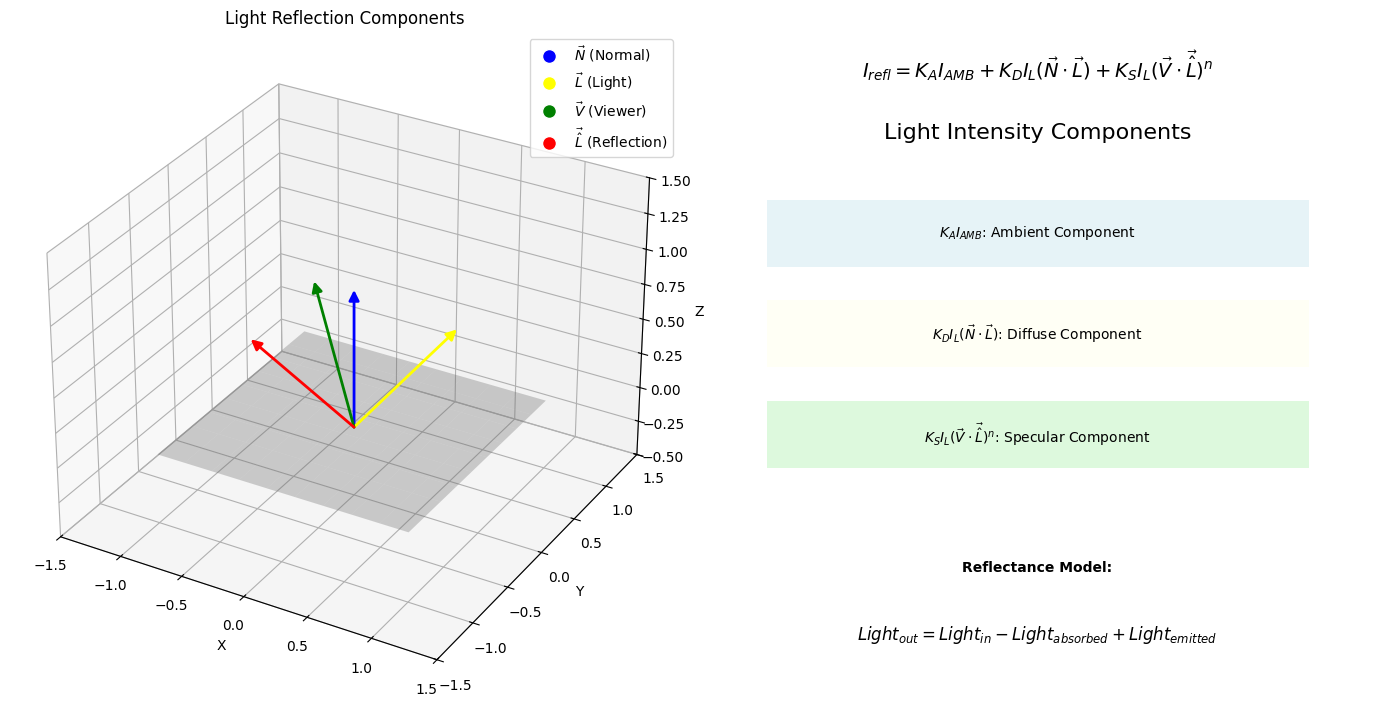

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import mpl_toolkits.mplot3d.art3d as art3d
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

# Create a 3D arrow class that works with newer Matplotlib versions
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._xyz = (xs, ys, zs)
        
    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._xyz
        xs, ys, _ = proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return np.min(zs3d)

# Create figure
fig = plt.figure(figsize=(14, 7))

# First create the light vectors diagram
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_xlim([-1.5, 1.5])
ax1.set_ylim([-1.5, 1.5])
ax1.set_zlim([-0.5, 1.5])
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title('Light Reflection Components')

# Draw surface (plane)
xx, yy = np.meshgrid(np.linspace(-1, 1, 10), np.linspace(-1, 1, 10))
zz = np.zeros(xx.shape)
ax1.plot_surface(xx, yy, zz, alpha=0.3, color='gray')

# Define vectors
origin = np.array([0, 0, 0])
normal = np.array([0, 0, 1])  # Normal vector
light = np.array([0.7, 0.5, 0.8])  # Light direction
light = light / np.linalg.norm(light)  # Normalize
viewer = np.array([-0.5, 0.3, 0.8])  # Viewer direction
viewer = viewer / np.linalg.norm(viewer)  # Normalize

# Calculate reflection vector
reflection = 2 * np.dot(normal, light) * normal - light
reflection = reflection / np.linalg.norm(reflection)  # Normalize

# Draw vectors
arrow_props = dict(mutation_scale=15, lw=2, arrowstyle='-|>', shrinkA=0)

n_arrow = Arrow3D([0, normal[0]], [0, normal[1]], [0, normal[2]], 
                 color='blue', **arrow_props)
l_arrow = Arrow3D([0, light[0]], [0, light[1]], [0, light[2]], 
                 color='yellow', **arrow_props)
v_arrow = Arrow3D([0, viewer[0]], [0, viewer[1]], [0, viewer[2]], 
                 color='green', **arrow_props)
r_arrow = Arrow3D([0, reflection[0]], [0, reflection[1]], [0, reflection[2]], 
                 color='red', **arrow_props)

# Add arrows to the plot
ax1.add_artist(n_arrow)
ax1.add_artist(l_arrow)
ax1.add_artist(v_arrow)
ax1.add_artist(r_arrow)

# Create custom legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label=r'$\vec{N}$ (Normal)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='yellow', markersize=10, label=r'$\vec{L}$ (Light)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10, label=r'$\vec{V}$ (Viewer)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label=r'$\vec{\hat{L}}$ (Reflection)')
]
ax1.legend(handles=legend_elements, loc='upper right')

# Now create the equation components diagram
ax2 = fig.add_subplot(122)
ax2.axis('off')

# Draw the reflection equation breakdown
components = [
    (r"$K_A I_{AMB}$", "Ambient Component", "lightblue"),
    (r"$K_D I_L (\vec{N} \cdot \vec{L})$", "Diffuse Component", "lightyellow"),
    (r"$K_S I_L (\vec{V} \cdot \vec{\hat{L}})^n$", "Specular Component", "lightgreen")
]

ax2.text(0.5, 0.95, r"$I_{refl} = K_A I_{AMB} + K_D I_L(\vec{N} \cdot \vec{L}) + K_S I_L(\vec{V} \cdot \vec{\hat{L}})^n$", 
         ha="center", va="center", fontsize=14)
ax2.text(0.5, 0.85, "Light Intensity Components", ha="center", va="center", fontsize=16)

for i, (eq, desc, color) in enumerate(components):
    y = 0.7 - i*0.15
    rect = plt.Rectangle((0.1, y-0.05), 0.8, 0.1, fc=color, alpha=0.3)
    ax2.add_patch(rect)
    ax2.text(0.5, y, f"{eq}: {desc}", ha="center", va="center")

# Add the reflectance model reminder
y_base = 0.2
ax2.text(0.5, y_base, "Reflectance Model:", ha="center", va="center", fontweight='bold')
ax2.text(0.5, y_base-0.1, r"$Light_{out} = Light_{in} - Light_{absorbed} + Light_{emitted}$", 
         ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.show()

##### Reminder on Reflectance model: 
The amount of light that is reflected from a surface on of an object is determined by the following formula: 
$$ Light_{out} = Light_{in} - Light_{absorbed} + Light_{emitted}$$

For the Phong-Reflectance model to be complete we must add the possibility that a perticular object is itself an emitter of light.

We'll just add a third light parameter: $I_E$  
$$I_{refl} = I_E + K_AI_{AMB} + K_DI_L(\vec{N} \cdot \vec{L}) + K_SI_L(\vec{V} \cdot \vec{\hat{L}})^n $$

